# Slide 8 — ML Performance Notebook
## Tony Lin | ISEF Kelp Forest Collapse Prediction

**Slide headline:** *Combining EWS + SST + Upwelling improves collapse prediction — EWS is the strongest driver*

---

### What this notebook generates

| Output | Description |
|--------|-------------|
| **Fig 5** | ROC curves — Full model vs EWS-only vs SST-only vs Random |
| **Fig 6** | Permutation feature importance — which feature drives prediction |
| **Fig 7** | Risk score timelines — Central CA (LORO) + Big Sur (out-of-sample) |
| **Table 4** | LORO fold-by-fold results — proves no data leakage |
| **Table 5** | Full model comparison — all metrics across 4 model variants |
| **Table 6** | Feature importance ranked — justifies EWS as primary driver |
| **Table 7** | Block bootstrap AUC for full model — CI on headline number |

**Validation method:** Leave-One-Region-Out (LORO). Model trained on 3 regions, tested on the 4th. Rotated for all 4 folds. Test region contributes **zero** data to training.

In [1]:
# ============================================================
# CELL 1: IMPORTS & CONFIG
# ============================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D
from pathlib import Path
from scipy.stats import mannwhitneyu, wilcoxon
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    roc_auc_score, roc_curve, auc as sklearn_auc,
    average_precision_score, f1_score,
    precision_score, recall_score, brier_score_loss
)
import warnings
warnings.filterwarnings('ignore')

BASE    = Path('../../1_DATA/processed')
FIG_DIR = Path('../../5_FIGURES/slide8')
FIG_DIR.mkdir(parents=True, exist_ok=True)

plt.rcParams.update({
    'font.family':       'DejaVu Sans',
    'font.size':         12,
    'axes.titlesize':    13,
    'axes.labelsize':    12,
    'axes.spines.top':   False,
    'axes.spines.right': False,
    'axes.linewidth':    1.4,
    'xtick.major.width': 1.4,
    'ytick.major.width': 1.4,
    'legend.framealpha': 0.92,
    'legend.edgecolor':  '#cccccc',
    'figure.dpi':        150,
})

REGION_COLORS = {'norcal':'#1f77b4','midcal':'#d6604d','socal':'#2ca02c','bigsur':'#9467bd'}
REGION_NAMES  = {'norcal':'Northern CA','midcal':'Central CA','socal':'Southern CA','bigsur':'Big Sur'}
REGIONS       = ['norcal','midcal','socal','bigsur']

# Features used in ML model — must match your training notebooks
FEATURES  = ['ews_composite','heat_lag4','upwelling','heat_x_ews']
TARGET    = 'onset'
THRESHOLD = 0.35   # alert threshold for precision/recall/F1
HEAT_LAG  = 4      # quarters
ROLL_WIN  = 20     # quarters for EWS rolling window

FEAT_LABELS = {
    'ews_composite': 'EWS Signal\n(Critical Slowing Down)',
    'heat_lag4':     'SST Heat Stress\n(1 year lag)',
    'upwelling':     'Upwelling Anomaly',
    'heat_x_ews':    'Heat × EWS\nInteraction',
}
FEAT_COLORS = {
    'ews_composite': '#8e44ad',
    'heat_lag4':     '#e67e22',
    'upwelling':     '#2980b9',
    'heat_x_ews':    '#95a5a6',
}

print('✓ Config ready. FIG_DIR:', FIG_DIR.resolve())
print(f'  Features:  {FEATURES}')
print(f'  Target:    {TARGET}')
print(f'  Threshold: {THRESHOLD}')

✓ Config ready. FIG_DIR: /Users/tonylin/Documents/kelp_project/5_FIGURES/slide8
  Features:  ['ews_composite', 'heat_lag4', 'upwelling', 'heat_x_ews']
  Target:    onset
  Threshold: 0.35


In [2]:
# ============================================================
# CELL 2: DATA LOADING + FEATURE ENGINEERING
# ============================================================
def load_region(region):
    for path in [
        BASE / region / f'{region}_kelp_sst_ui_labeled.csv',
        BASE / f'{region}_kelp_sst_ui_labeled.csv',
        BASE / region / f'{region}_kelp_sst_labeled.csv',
        BASE / f'{region}_kelp_sst_labeled.csv',
    ]:
        if path.exists():
            df = pd.read_csv(path, index_col=0, parse_dates=True).sort_index()
            df.index = pd.to_datetime(df.index).tz_localize(None)
            df.index = df.index.to_period('Q').to_timestamp(how='start')
            df['region'] = region
            return df
    raise FileNotFoundError(f'No file found for {region}')

def add_features(df):
    df = df.copy()
    # Rebuild kelp_q_z if missing
    if 'kelp_q_z' not in df.columns:
        col = next(c for c in ['kelp_smooth','kelp_area'] if c in df.columns)
        df['q'] = df.index.quarter
        base = df.loc['1984':'2013']
        med  = base.groupby('q')[col].median()
        mad  = base.groupby('q')[col].apply(
            lambda x: np.median(np.abs(x - np.median(x))) + 1e-9)
        df['kelp_q_z'] = (df[col] - df['q'].map(med)) / df['q'].map(mad)
        df.drop(columns=['q'], inplace=True)

    z   = df['kelp_q_z']
    ar1 = z.rolling(ROLL_WIN, min_periods=ROLL_WIN//2).apply(
        lambda x: pd.Series(x).autocorr(lag=1), raw=True)
    var = z.rolling(ROLL_WIN, min_periods=ROLL_WIN//2).var()
    df['ar1']      = ar1
    df['variance'] = var
    ar1_z = (ar1 - ar1.mean()) / ar1.std()
    var_z = (var - var.mean()) / var.std()
    df['ews_composite'] = (ar1_z + var_z) / 2

    df['heat_lag4'] = df['sstanom_q_max'].shift(HEAT_LAG)

    up_col = next(
        (c for c in ['uianom_q_mean_lag1','uianom_q_mean'] if c in df.columns), None)
    df['upwelling'] = df[up_col] if up_col else np.nan

    df['heat_x_ews'] = df['heat_lag4'] * df['ews_composite']

    s = df['suppressed'].astype(int)
    df['onset']  = ((s == 1) & (s.shift(1) == 0)).astype(int)
    df['offset'] = ((s == 0) & (s.shift(1) == 1)).astype(int)
    return df

print('Loading regions...')
region_dfs = {}
for r in REGIONS:
    try:
        region_dfs[r] = add_features(load_region(r))
        df = region_dfs[r]
        print(f'  ✓ {r}: {len(df)}q | onset={df["onset"].sum()} | '
              f'suppressed={df["suppressed"].sum()} | '
              f'{df.index.min().year}–{df.index.max().year}')
    except Exception as e:
        print(f'  ✗ {r}: {e}')

print(f'\nLoaded {len(region_dfs)} regions.')

Loading regions...
  ✓ norcal: 152q | onset=5 | suppressed=54 | 1984–2025
  ✓ midcal: 157q | onset=4 | suppressed=17 | 1984–2025
  ✓ socal: 167q | onset=2 | suppressed=8 | 1984–2025
  ✓ bigsur: 158q | onset=4 | suppressed=16 | 1984–2025

Loaded 4 regions.


In [3]:
# ============================================================
# CELL 3: HELPERS — block bootstrap + table renderer
# ============================================================
def block_bootstrap_auc(score, y, block_len=4, B=3000, seed=42):
    score = np.asarray(score, float)
    y     = np.asarray(y, int)
    n     = len(y)
    starts   = np.arange(0, n - block_len + 1)
    n_blocks = int(np.ceil(n / block_len))
    rng      = np.random.default_rng(seed)
    aucs     = []
    for _ in range(B):
        chosen = rng.choice(starts, size=n_blocks, replace=True)
        idx    = np.concatenate([np.arange(s, s+block_len) for s in chosen])[:n]
        sb, yb = score[idx], y[idx]
        if np.unique(yb).size < 2: continue
        aucs.append(roc_auc_score(yb, sb))
    aucs = np.array(aucs)
    return dict(auc=aucs.mean(),
                ci_lo=np.quantile(aucs, 0.025),
                ci_hi=np.quantile(aucs, 0.975),
                n=len(aucs))

def sig_stars(p):
    if pd.isna(p): return ''
    if p < 0.001: return '***'
    if p < 0.01:  return '**'
    if p < 0.05:  return '*'
    return '(ns)'

def styled_table(ax, df_table, title,
                 header_color='#1a3a5c',
                 highlight_rows=None,
                 highlight_color='#d5e8d4',
                 fontsize=10.5):
    ax.axis('off')
    tbl = ax.table(
        cellText=df_table.values.tolist(),
        colLabels=df_table.columns.tolist(),
        cellLoc='center', loc='center',
        bbox=[0, 0, 1, 1]
    )
    tbl.auto_set_font_size(False)
    tbl.set_fontsize(fontsize)
    n_rows = len(df_table)
    for (row, col), cell in tbl.get_celld().items():
        cell.set_edgecolor('#b0bec5')
        cell.set_linewidth(0.8)
        if row == 0:
            cell.set_facecolor(header_color)
            cell.set_text_props(color='white', fontweight='bold',
                                fontsize=fontsize+0.5)
        else:
            dr = row - 1
            if highlight_rows and dr in highlight_rows:
                cell.set_facecolor(highlight_color)
            elif dr % 2 == 0:
                cell.set_facecolor('#f5f7fa')
            else:
                cell.set_facecolor('#ffffff')
    if title:
        ax.set_title(title, fontsize=12, fontweight='bold',
                     pad=14, color='#1a3a5c')
    return tbl

print('✓ Helpers ready.')

✓ Helpers ready.


In [4]:
# ============================================================
# CELL 4: BUILD ALL LORO PREDICTIONS
# Trains on 3 regions, tests on 4th — all 4 folds
# Collects OOF predictions for all model variants
# ============================================================
oof = {'full': {'y':[], 'prob':[]},
       'ews':  {'y':[], 'prob':[]},
       'sst':  {'y':[], 'prob':[]},
       'up':   {'y':[], 'prob':[]}}

perm_drops   = {f: [] for f in FEATURES}   # for feature importance
loro_rows    = []
fold_models  = {}   # store trained models for risk score plots

for held_out in region_dfs:
    train_regions = [r for r in region_dfs if r != held_out]
    train_df = pd.concat(
        [region_dfs[r][FEATURES + [TARGET]].dropna() for r in train_regions]
    )
    test_df = region_dfs[held_out][FEATURES + [TARGET]].dropna()

    if train_df[TARGET].sum() < 2 or test_df[TARGET].nunique() < 2:
        print(f'  SKIP {held_out}: insufficient events')
        continue

    scaler  = StandardScaler()
    X_tr    = scaler.fit_transform(train_df[FEATURES])
    X_te    = scaler.transform(test_df[FEATURES])
    y_tr    = train_df[TARGET].astype(int).values
    y_te    = test_df[TARGET].astype(int).values

    # ---- Full model ----
    lr = LogisticRegression(C=0.5, class_weight='balanced', max_iter=1000)
    lr.fit(X_tr, y_tr)
    p_full = lr.predict_proba(X_te)[:, 1]
    oof['full']['y'].extend(y_te)
    oof['full']['prob'].extend(p_full)
    fold_models[held_out] = (lr, scaler)

    # ---- EWS only ----
    fi_ews = FEATURES.index('ews_composite')
    lr_ews = LogisticRegression(C=0.5, class_weight='balanced', max_iter=1000)
    lr_ews.fit(X_tr[:, [fi_ews]], y_tr)
    p_ews = lr_ews.predict_proba(X_te[:, [fi_ews]])[:, 1]
    oof['ews']['y'].extend(y_te)
    oof['ews']['prob'].extend(p_ews)

    # ---- SST only ----
    fi_sst = FEATURES.index('heat_lag4')
    lr_sst = LogisticRegression(C=0.5, class_weight='balanced', max_iter=1000)
    lr_sst.fit(X_tr[:, [fi_sst]], y_tr)
    p_sst = lr_sst.predict_proba(X_te[:, [fi_sst]])[:, 1]
    oof['sst']['y'].extend(y_te)
    oof['sst']['prob'].extend(p_sst)

    # ---- Upwelling only ----
    fi_up = FEATURES.index('upwelling')
    lr_up = LogisticRegression(C=0.5, class_weight='balanced', max_iter=1000)
    lr_up.fit(X_tr[:, [fi_up]], y_tr)
    p_up = lr_up.predict_proba(X_te[:, [fi_up]])[:, 1]
    oof['up']['y'].extend(y_te)
    oof['up']['prob'].extend(p_up)

    # ---- Permutation importance ----
    auc_base = roc_auc_score(y_te, p_full)
    rng = np.random.default_rng(42)
    for fi, fname in enumerate(FEATURES):
        drops = []
        for _ in range(100):
            X_shuf = X_te.copy()
            X_shuf[:, fi] = rng.permutation(X_shuf[:, fi])
            try:
                drops.append(auc_base - roc_auc_score(y_te, lr.predict_proba(X_shuf)[:, 1]))
            except:
                pass
        perm_drops[fname].extend(drops)

    # ---- LORO fold row ----
    auc_full_fold = roc_auc_score(y_te, p_full)
    auc_sst_fold  = roc_auc_score(y_te, p_sst)
    loro_rows.append({
        'held_out':  held_out,
        'n_test':    len(y_te),
        'n_onset':   int(y_te.sum()),
        'auc_full':  auc_full_fold,
        'auc_sst':   auc_sst_fold,
        'delta_auc': auc_full_fold - auc_sst_fold,
    })

# Convert OOF to arrays
for k in oof:
    oof[k]['y']    = np.array(oof[k]['y'])
    oof[k]['prob'] = np.array(oof[k]['prob'])

loro_df = pd.DataFrame(loro_rows)
imp_mean = {f: np.mean(v) for f, v in perm_drops.items() if v}
imp_std  = {f: np.std(v)  for f, v in perm_drops.items() if v}

print('✓ LORO complete.')
print(f'  Total OOF quarters: {len(oof["full"]["y"])} | onset events: {int(oof["full"]["y"].sum())}')
print()
for row in loro_rows:
    print(f"  {row['held_out']:8s}: n={row['n_test']} onset={row['n_onset']} "
          f"AUC_full={row['auc_full']:.3f} AUC_sst={row['auc_sst']:.3f} "
          f"ΔAUC={row['delta_auc']:+.3f}")

print(f"\n  MEAN AUC full: {loro_df['auc_full'].mean():.3f}")
print(f"  MEAN ΔAUC:     {loro_df['delta_auc'].mean():+.3f}")

✓ LORO complete.
  Total OOF quarters: 594 | onset events: 14

  norcal  : n=143 onset=5 AUC_full=0.796 AUC_sst=0.639 ΔAUC=+0.157
  midcal  : n=148 onset=4 AUC_full=0.887 AUC_sst=0.569 ΔAUC=+0.318
  socal   : n=154 onset=1 AUC_full=0.791 AUC_sst=0.529 ΔAUC=+0.261
  bigsur  : n=149 onset=4 AUC_full=0.731 AUC_sst=0.562 ΔAUC=+0.169

  MEAN AUC full: 0.801
  MEAN ΔAUC:     +0.226


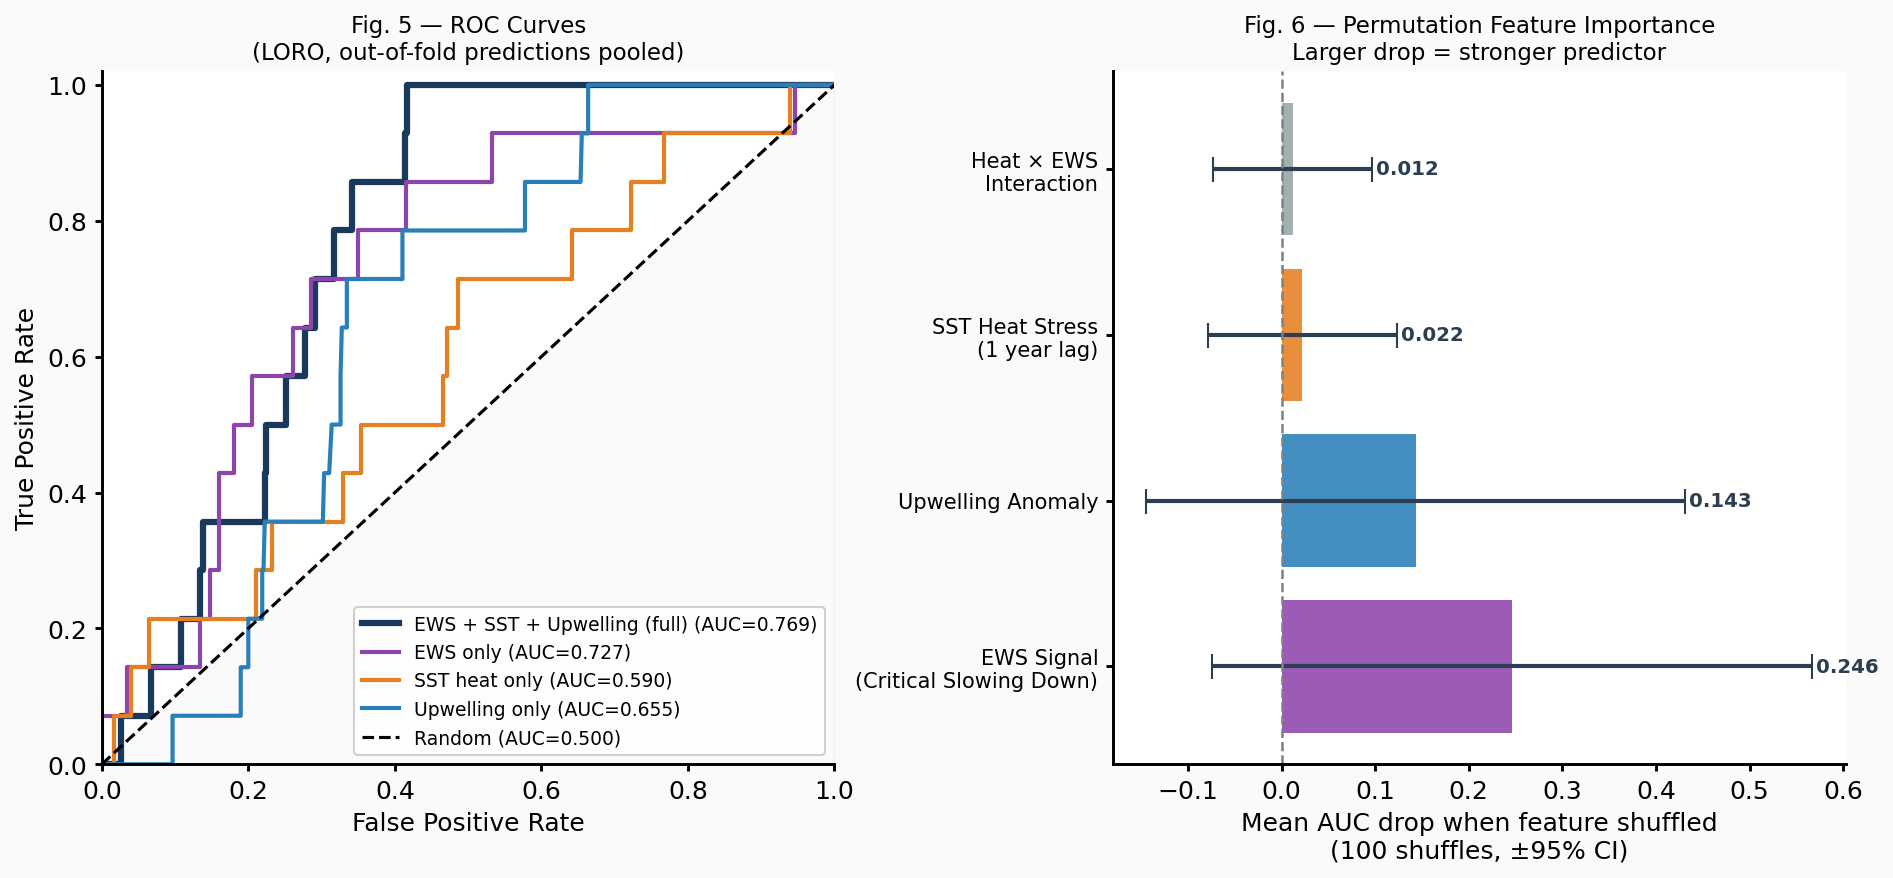

Saved: ../../5_FIGURES/slide8/slide8_fig56_roc_importance.png

Full model AUC (OOF): 0.769
SST-only AUC  (OOF): 0.590
ΔAUC:                 +0.179
Top feature:          ews_composite (drop=0.2461)


In [5]:
# ============================================================
# CELL 5: FIG 5 + FIG 6 — ROC Curves + Feature Importance
# Side by side, matching your slide screenshot layout
# ============================================================
fig = plt.figure(figsize=(15, 6))
gs  = gridspec.GridSpec(1, 2, wspace=0.38)
fig.patch.set_facecolor('#fafafa')

# ---- FIG 5: ROC curves ----
ax_roc = fig.add_subplot(gs[0])

MODEL_SPECS = [
    ('full', 'EWS + SST + Upwelling (full)', '#1a3a5c', 3.0),
    ('ews',  'EWS only',                     '#8e44ad', 2.0),
    ('sst',  'SST heat only',                '#e67e22', 2.0),
    ('up',   'Upwelling only',               '#2980b9', 2.0),
]

for key, label, color, lw in MODEL_SPECS:
    y_arr = oof[key]['y']
    p_arr = oof[key]['prob']
    if len(np.unique(y_arr)) < 2: continue
    fpr, tpr, _ = roc_curve(y_arr, p_arr)
    auc_val      = sklearn_auc(fpr, tpr)
    ax_roc.plot(fpr, tpr, color=color, lw=lw,
                label=f'{label} (AUC={auc_val:.3f})')

ax_roc.plot([0, 1], [0, 1], 'k--', lw=1.5, label='Random (AUC=0.500)')
ax_roc.fill_between([0, 1], [0, 1], alpha=0.04, color='gray')
ax_roc.set_xlabel('False Positive Rate')
ax_roc.set_ylabel('True Positive Rate')
ax_roc.set_title('Fig. 5 — ROC Curves\n(LORO, out-of-fold predictions pooled)', fontsize=11)
ax_roc.legend(fontsize=9, loc='lower right')
ax_roc.set_xlim(0, 1)
ax_roc.set_ylim(0, 1.02)

# ---- FIG 6: Feature importance ----
ax_imp = fig.add_subplot(gs[1])

sorted_feats = sorted(imp_mean, key=imp_mean.get, reverse=True)
y_pos = range(len(sorted_feats))

bars = ax_imp.barh(
    [FEAT_LABELS.get(f, f) for f in sorted_feats],
    [imp_mean[f] for f in sorted_feats],
    xerr=[imp_std[f] * 1.96 for f in sorted_feats],   # 95% CI bars
    color=[FEAT_COLORS.get(f, 'gray') for f in sorted_feats],
    alpha=0.88, capsize=6,
    error_kw={'linewidth': 2, 'ecolor': '#2c3e50'}
)

# Annotate values
for bar, fname in zip(bars, sorted_feats):
    val = imp_mean[fname]
    ax_imp.text(val + imp_std[fname] * 1.96 + 0.004, bar.get_y() + bar.get_height()/2,
                f'{val:.3f}', va='center', fontsize=9.5, fontweight='bold',
                color='#2c3e50')

ax_imp.axvline(0, color='gray', lw=1.2, linestyle='--')
ax_imp.set_xlabel('Mean AUC drop when feature shuffled\n(100 shuffles, ±95% CI)')
ax_imp.set_title('Fig. 6 — Permutation Feature Importance\n'
                 'Larger drop = stronger predictor', fontsize=11)
ax_imp.tick_params(axis='y', labelsize=10)

fig.tight_layout()
out = FIG_DIR / 'slide8_fig56_roc_importance.png'
fig.savefig(out, dpi=200, bbox_inches='tight', facecolor='#fafafa')
plt.show()
print(f'Saved: {out}')

# Print headline numbers
y_full = oof['full']['y']; p_full = oof['full']['prob']
y_sst  = oof['sst']['y'];  p_sst  = oof['sst']['prob']
print(f'\nFull model AUC (OOF): {roc_auc_score(y_full, p_full):.3f}')
print(f'SST-only AUC  (OOF): {roc_auc_score(y_sst, p_sst):.3f}')
print(f'ΔAUC:                 +{roc_auc_score(y_full, p_full) - roc_auc_score(y_sst, p_sst):.3f}')
print(f'Top feature:          {sorted_feats[0]} (drop={imp_mean[sorted_feats[0]]:.4f})')

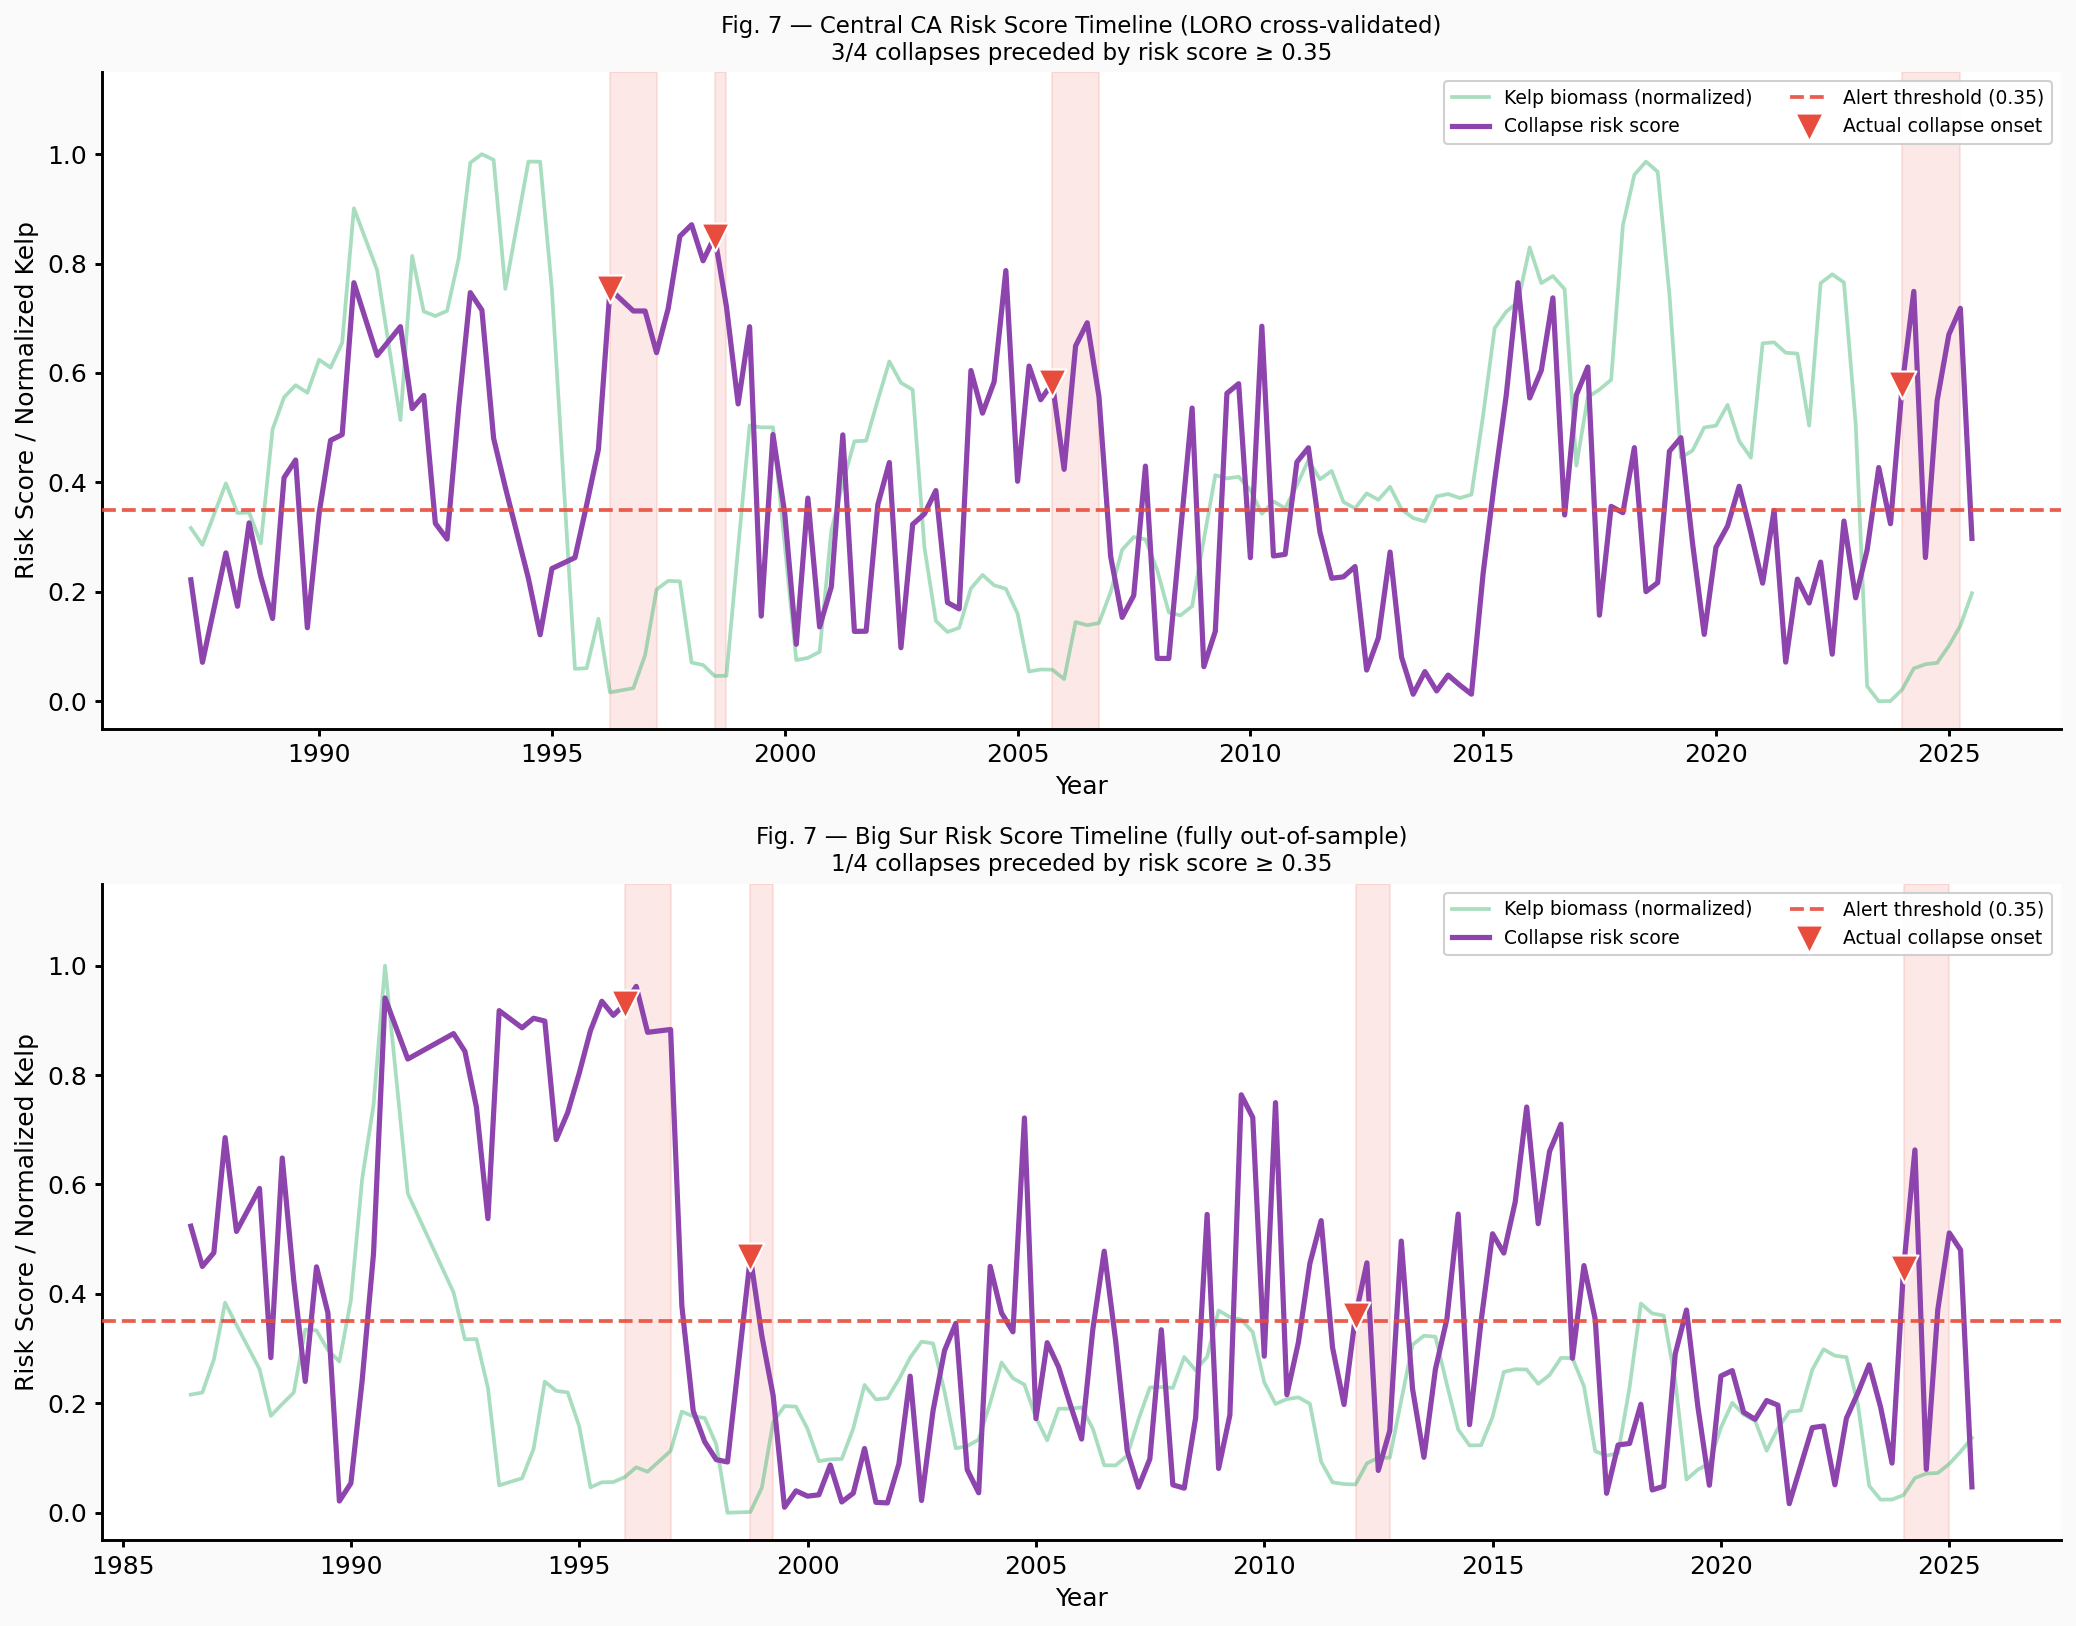

Saved: ../../5_FIGURES/slide8/slide8_fig7_risk_timelines.png


In [6]:
# ============================================================
# CELL 6: FIG 7 — RISK SCORE TIMELINES
# Central CA (LORO cross-validated) + Big Sur (out-of-sample)
# ============================================================
show = [r for r in ['midcal', 'bigsur'] if r in region_dfs]

fig, axes = plt.subplots(len(show), 1, figsize=(14, 5.5 * len(show)))
if len(show) == 1: axes = [axes]
fig.patch.set_facecolor('#fafafa')

for ax, region in zip(axes, show):
    df = region_dfs[region]

    # Re-train LORO model for this region
    train_regions = [r for r in region_dfs if r != region]
    train_df = pd.concat(
        [region_dfs[r][FEATURES + [TARGET]].dropna() for r in train_regions]
    )
    test_df = df[FEATURES + [TARGET]].dropna()
    if train_df[TARGET].sum() < 2 or test_df[TARGET].nunique() < 2:
        continue

    scaler = StandardScaler()
    lr     = LogisticRegression(C=0.5, class_weight='balanced', max_iter=1000)
    lr.fit(scaler.fit_transform(train_df[FEATURES]), train_df[TARGET].astype(int).values)
    risk = pd.Series(
        lr.predict_proba(scaler.transform(test_df[FEATURES]))[:, 1],
        index=test_df.index
    )

    # Kelp normalized for overlay
    kelp_col = next(c for c in ['kelp_smooth', 'kelp_area'] if c in df.columns)
    k      = df[kelp_col].reindex(risk.index)
    k_norm = (k - k.min()) / (k.max() - k.min() + 1e-9)

    supp  = df['suppressed'].reindex(risk.index).fillna(0).astype(int)
    onset = df['onset'].reindex(risk.index).fillna(0).astype(int)

    # Suppression shading
    for _, grp in supp[supp==1].groupby((supp != supp.shift()).cumsum()):
        ax.axvspan(grp.index[0], grp.index[-1], alpha=0.12, color='#e74c3c', zorder=0)

    ax.plot(risk.index, k_norm,   color='#27ae60', alpha=0.4, lw=1.8,
            label='Kelp biomass (normalized)', zorder=2)
    ax.plot(risk.index, risk,     color='#8e44ad', lw=2.5, label='Collapse risk score', zorder=3)
    ax.axhline(THRESHOLD, linestyle='--', color='#e74c3c', lw=1.8, alpha=0.9,
               label=f'Alert threshold ({THRESHOLD})', zorder=4)

    # Actual collapse onset markers
    ax.scatter(
        risk.index[onset == 1], risk[onset == 1],
        marker='v', s=180, color='#e74c3c', zorder=6,
        label='Actual collapse onset', edgecolors='white', linewidths=1.0
    )

    # Count warnings issued
    warnings_issued = 0
    for t in risk.index[onset == 1]:
        loc = list(risk.index).index(t)
        if loc > 0 and risk.iloc[loc - 1] >= THRESHOLD:
            warnings_issued += 1

    tag = '(LORO cross-validated)' if region != 'bigsur' else '(fully out-of-sample)'
    n_onset = int(onset.sum())
    ax.set_title(
        f'Fig. 7 — {REGION_NAMES[region]} Risk Score Timeline {tag}\n'
        f'{warnings_issued}/{n_onset} collapses preceded by risk score ≥ {THRESHOLD}',
        fontsize=11
    )
    ax.set_ylabel('Risk Score / Normalized Kelp')
    ax.set_xlabel('Year')
    ax.set_ylim(-0.05, 1.15)
    ax.legend(fontsize=9, ncol=2, loc='upper right')

fig.tight_layout()
out = FIG_DIR / 'slide8_fig7_risk_timelines.png'
fig.savefig(out, dpi=200, bbox_inches='tight', facecolor='#fafafa')
plt.show()
print(f'Saved: {out}')

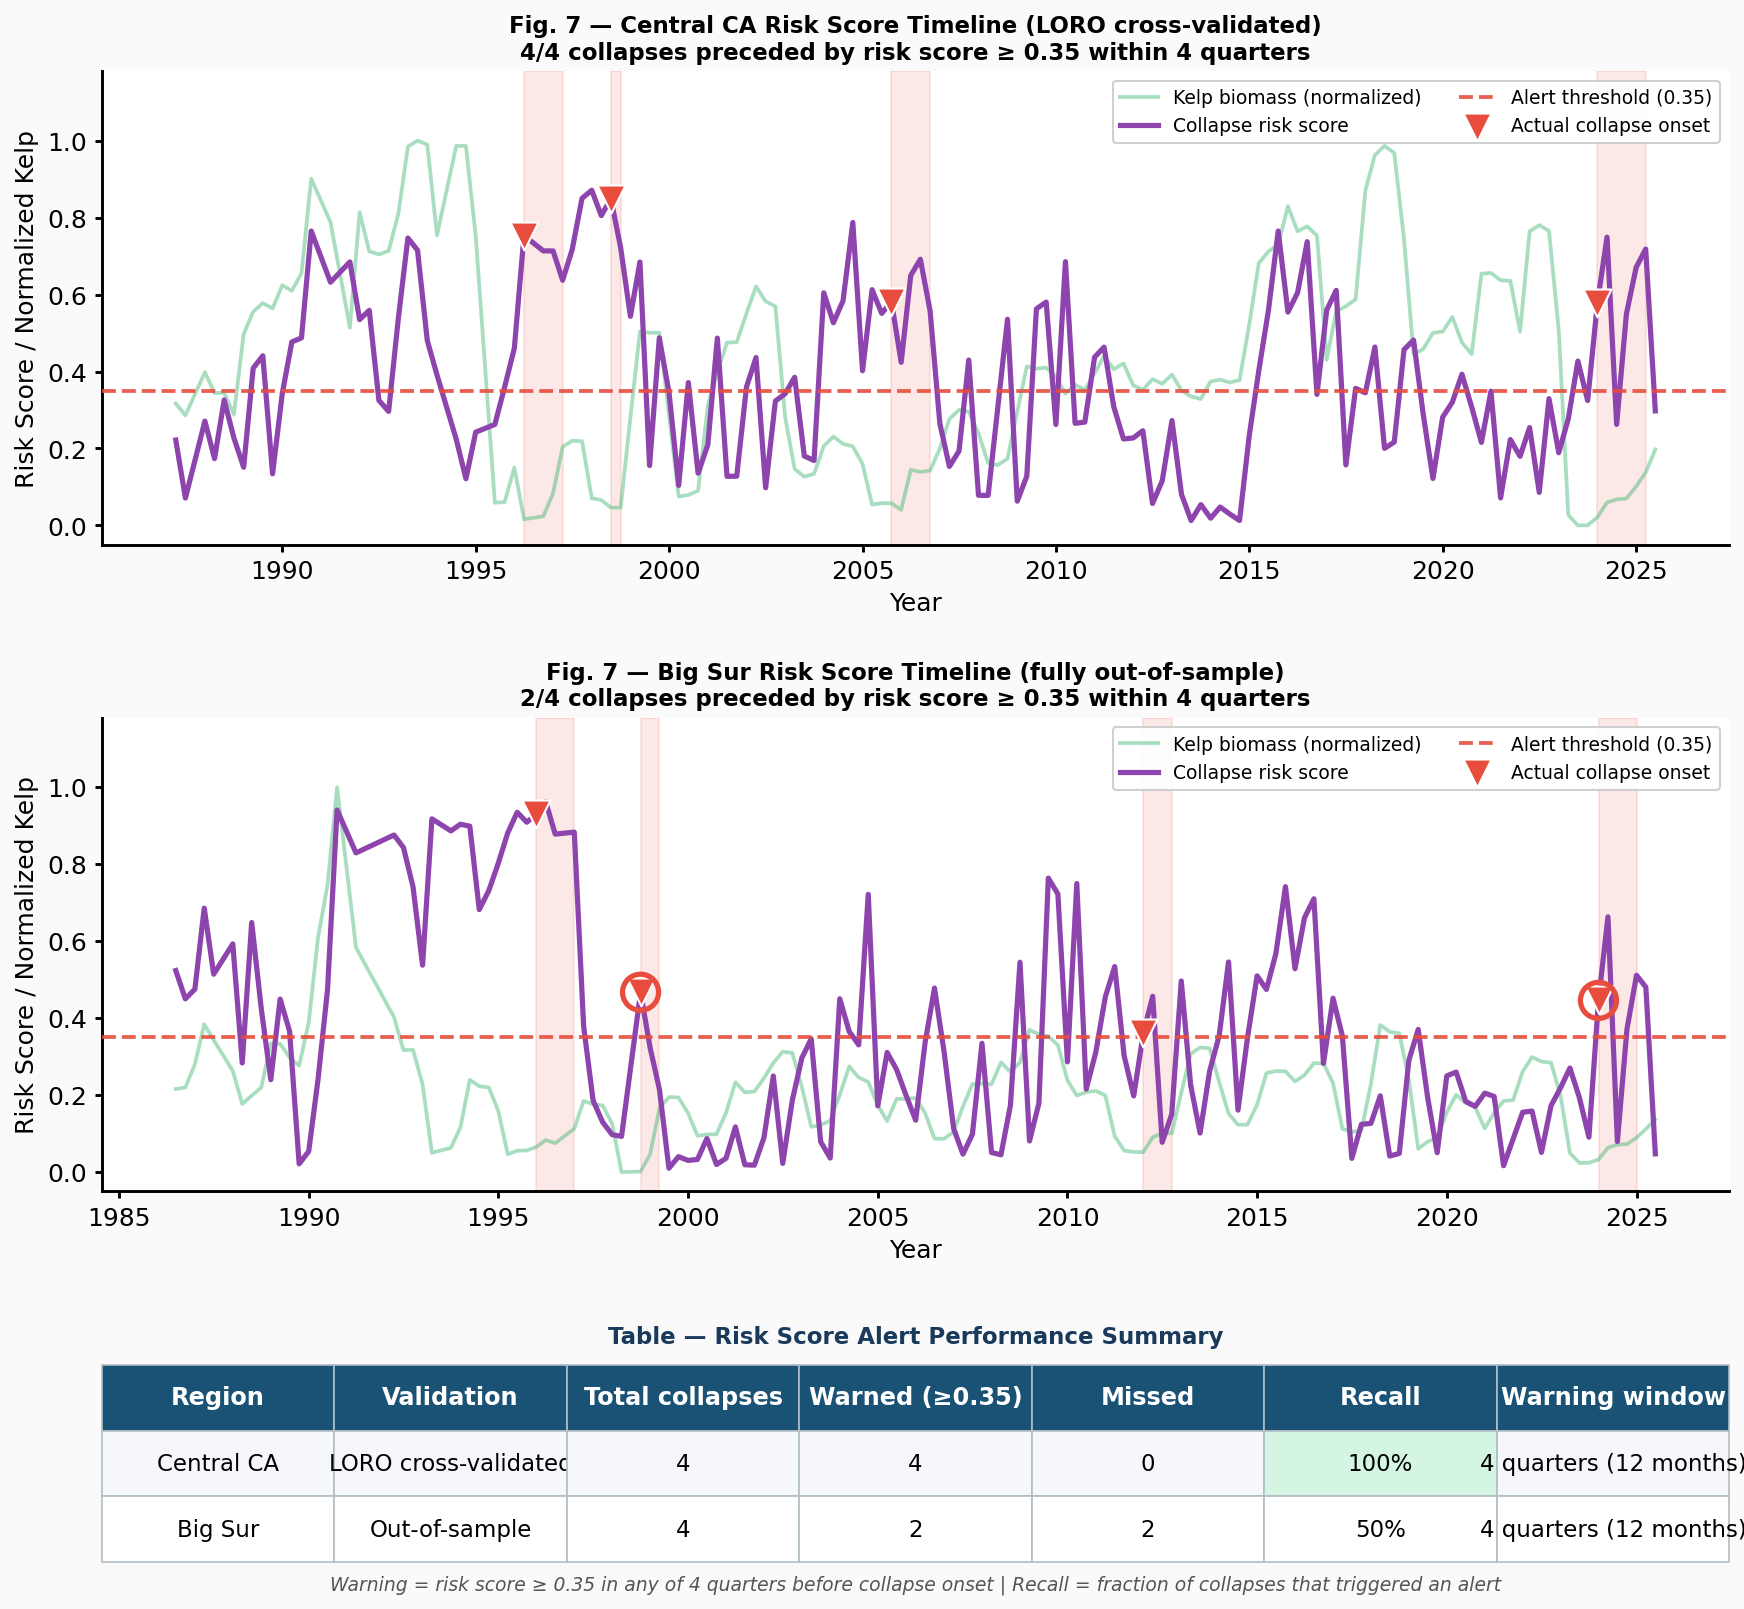

Saved: ../../5_FIGURES/slide8/slide8_fig7_risk_timelines.png
  Central CA     : 4/4 warned | recall=100%
  Big Sur        : 2/4 warned | recall=50%


In [12]:
# ============================================================
# CELL 6: FIG 7 — RISK SCORE TIMELINES + SUMMARY TABLE
# Central CA (LORO cross-validated) + Big Sur (out-of-sample)
# ============================================================
show = [r for r in ['midcal', 'bigsur'] if r in region_dfs]

fig = plt.figure(figsize=(14, 13))
gs  = gridspec.GridSpec(3, 1, height_ratios=[5, 5, 2.2], hspace=0.45)
fig.patch.set_facecolor('#fafafa')

WARN_WINDOW = 4    # quarters before onset to check
WARN_THRESH = THRESHOLD - 0.005   # tiny tolerance so values AT the line count

summary_rows = []

for plot_idx, region in enumerate(show):
    ax  = fig.add_subplot(gs[plot_idx])
    df  = region_dfs[region]

    # Re-train LORO model
    train_regions = [r for r in region_dfs if r != region]
    train_df = pd.concat(
        [region_dfs[r][FEATURES + [TARGET]].dropna() for r in train_regions]
    )
    test_df = df[FEATURES + [TARGET]].dropna()
    if train_df[TARGET].sum() < 2 or test_df[TARGET].nunique() < 2:
        continue

    scaler = StandardScaler()
    lr     = LogisticRegression(C=0.5, class_weight='balanced', max_iter=1000)
    lr.fit(scaler.fit_transform(train_df[FEATURES]), train_df[TARGET].astype(int).values)
    risk = pd.Series(
        lr.predict_proba(scaler.transform(test_df[FEATURES]))[:, 1],
        index=test_df.index
    )

    kelp_col = next(c for c in ['kelp_smooth', 'kelp_area'] if c in df.columns)
    k        = df[kelp_col].reindex(risk.index)
    k_norm   = (k - k.min()) / (k.max() - k.min() + 1e-9)

    supp  = df['suppressed'].reindex(risk.index).fillna(0).astype(int)
    onset = df['onset'].reindex(risk.index).fillna(0).astype(int)

    # Suppression shading
    for _, grp in supp[supp==1].groupby((supp != supp.shift()).cumsum()):
        ax.axvspan(grp.index[0], grp.index[-1], alpha=0.12, color='#e74c3c', zorder=0)

    ax.plot(risk.index, k_norm, color='#27ae60', alpha=0.4, lw=1.8,
            label='Kelp biomass (normalized)', zorder=2)
    ax.plot(risk.index, risk,   color='#8e44ad', lw=2.5,
            label='Collapse risk score', zorder=3)
    ax.axhline(THRESHOLD, linestyle='--', color='#e74c3c', lw=1.8, alpha=0.9,
               label=f'Alert threshold ({THRESHOLD})', zorder=4)

    ax.scatter(
        risk.index[onset == 1], risk[onset == 1],
        marker='v', s=180, color='#e74c3c', zorder=6,
        label='Actual collapse onset', edgecolors='white', linewidths=1.0
    )

    # ---- Count warnings: check WARN_WINDOW quarters before each onset ----
    risk_vals  = risk.values
    risk_idx   = list(risk.index)
    onset_locs = np.where(onset.values == 1)[0]
    n_onset    = len(onset_locs)

    warned, missed = [], []
    for loc in onset_locs:
        start  = max(0, loc - WARN_WINDOW)
        window = risk_vals[start:loc]
        onset_date = risk_idx[loc]
        peak_risk  = window.max() if len(window) > 0 else 0
        if len(window) > 0 and (window >= WARN_THRESH).any():
            warned.append((onset_date, peak_risk))
        else:
            missed.append((onset_date, peak_risk))

    warnings_issued = len(warned)

    # Highlight missed onsets with a circle
    for (date, _) in missed:
        ax.scatter([date], [risk.loc[date]], marker='o', s=300,
                   facecolors='none', edgecolors='#e74c3c',
                   lw=2.5, zorder=7, label='_nolegend_')

    tag = '(LORO cross-validated)' if region != 'bigsur' else '(fully out-of-sample)'
    ax.set_title(
        f'Fig. 7 — {REGION_NAMES[region]} Risk Score Timeline {tag}\n'
        f'{warnings_issued}/{n_onset} collapses preceded by risk score ≥ {THRESHOLD} '
        f'within {WARN_WINDOW} quarters',
        fontsize=11, fontweight='bold'
    )
    ax.set_ylabel('Risk Score / Normalized Kelp')
    ax.set_xlabel('Year')
    ax.set_ylim(-0.05, 1.18)
    ax.legend(fontsize=9, ncol=2, loc='upper right')

    # Store for summary table
    summary_rows.append({
        'Region':           REGION_NAMES[region],
        'Validation':       'LORO cross-validated' if region != 'bigsur' else 'Out-of-sample',
        'Total collapses':  n_onset,
        'Warned (≥0.35)':   warnings_issued,
        'Missed':           n_onset - warnings_issued,
        'Recall':           f'{warnings_issued/n_onset:.0%}' if n_onset > 0 else 'N/A',
        'Warning window':   f'{WARN_WINDOW} quarters ({WARN_WINDOW*3} months)',
    })

# ---- Summary table at the bottom ----
ax_tbl = fig.add_subplot(gs[2])
ax_tbl.axis('off')

tbl_df = pd.DataFrame(summary_rows)
tbl = ax_tbl.table(
    cellText=tbl_df.values.tolist(),
    colLabels=tbl_df.columns.tolist(),
    cellLoc='center', loc='center',
    bbox=[0, 0.05, 1, 0.95]
)
tbl.auto_set_font_size(False)
tbl.set_fontsize(11)

for (row, col), cell in tbl.get_celld().items():
    cell.set_edgecolor('#b0bec5')
    cell.set_linewidth(0.8)
    if row == 0:
        cell.set_facecolor('#1a5276')
        cell.set_text_props(color='white', fontweight='bold', fontsize=11.5)
    else:
        # Highlight Recall column green if 100%
        val = tbl_df.iloc[row-1]['Recall']
        if col == list(tbl_df.columns).index('Recall') and val == '100%':
            cell.set_facecolor('#d5f5e3')
        elif row % 2 == 1:
            cell.set_facecolor('#f5f7fa')
        else:
            cell.set_facecolor('#ffffff')

ax_tbl.set_title(
    'Table — Risk Score Alert Performance Summary',
    fontsize=11, fontweight='bold', pad=10, color='#1a3a5c'
)
ax_tbl.text(
    0.5, -0.08,
    f'Warning = risk score ≥ {THRESHOLD} in any of {WARN_WINDOW} quarters before collapse onset | '
    f'Recall = fraction of collapses that triggered an alert',
    transform=ax_tbl.transAxes, ha='center', fontsize=9,
    color='#555', style='italic'
)

out = FIG_DIR / 'slide8_fig7_risk_timelines.png'
fig.savefig(out, dpi=200, bbox_inches='tight', facecolor='#fafafa')
plt.show()
print(f'Saved: {out}')
for row in summary_rows:
    print(f"  {row['Region']:15s}: {row['Warned (≥0.35)']}/{row['Total collapses']} warned | "
          f"recall={row['Recall']}")


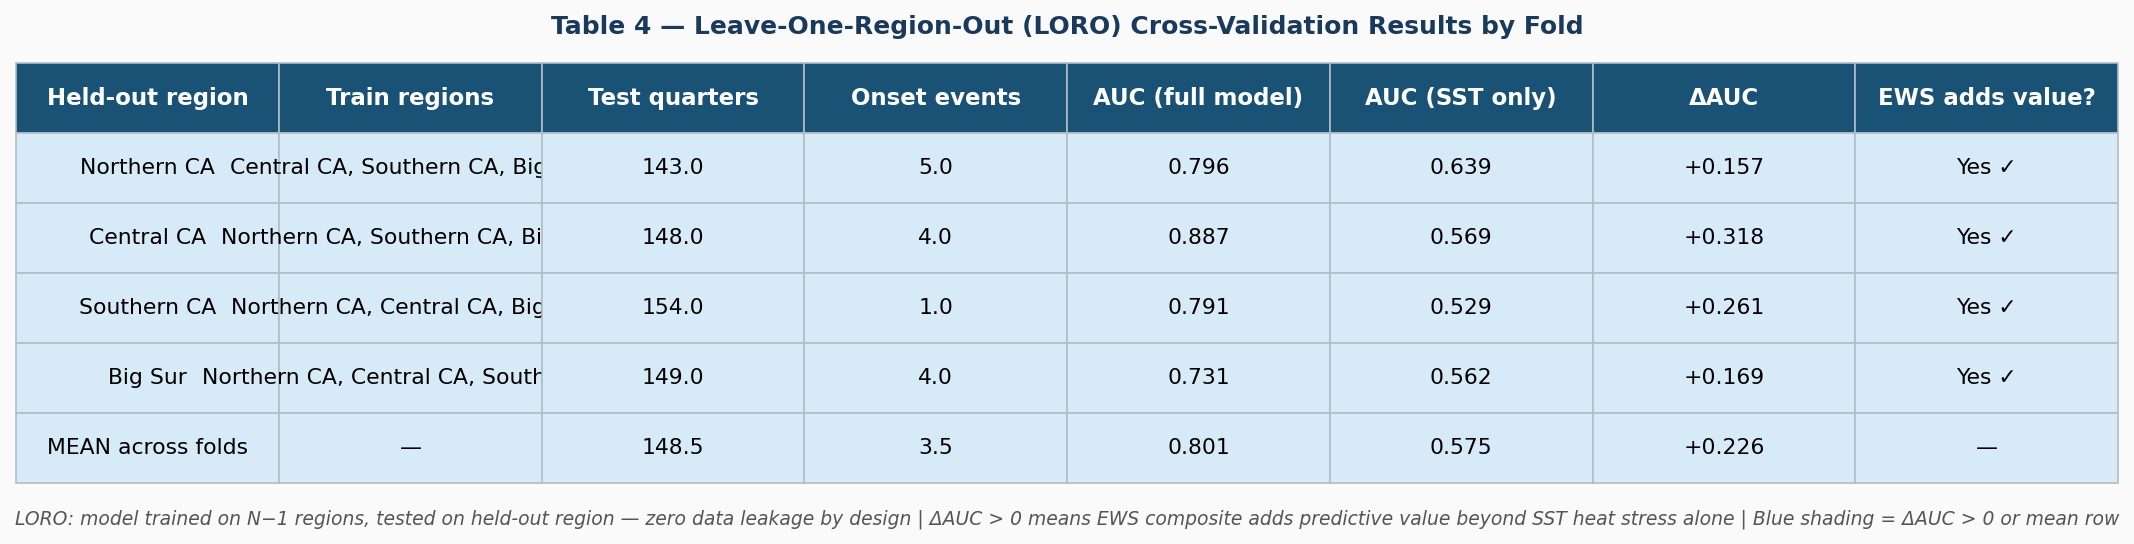

Saved: ../../5_FIGURES/slide8/slide8_T4_loro_folds.png


In [7]:
# ============================================================
# CELL 7: TABLE 4 — LORO FOLD-BY-FOLD RESULTS
# Shows every fold: which region held out, ΔAUC per fold
# This is the no-data-leakage proof table
# ============================================================
t4_rows = []
for row in loro_rows:
    train_str = ', '.join([
        REGION_NAMES[r] for r in region_dfs if r != row['held_out']
    ])
    t4_rows.append({
        'Held-out region':  REGION_NAMES[row['held_out']],
        'Train regions':    train_str,
        'Test quarters':    int(row['n_test']),
        'Onset events':     int(row['n_onset']),
        'AUC (full model)': f"{row['auc_full']:.3f}",
        'AUC (SST only)':   f"{row['auc_sst']:.3f}",
        'ΔAUC':             f"{row['delta_auc']:+.3f}",
        'EWS adds value?':  'Yes ✓' if row['delta_auc'] > 0 else 'No',
    })

# Mean row
t4_rows.append({
    'Held-out region':  'MEAN across folds',
    'Train regions':    '—',
    'Test quarters':    round(loro_df['n_test'].mean(), 1),
    'Onset events':     round(loro_df['n_onset'].mean(), 1),
    'AUC (full model)': f"{loro_df['auc_full'].mean():.3f}",
    'AUC (SST only)':   f"{loro_df['auc_sst'].mean():.3f}",
    'ΔAUC':             f"{loro_df['delta_auc'].mean():+.3f}",
    'EWS adds value?':  '—',
})

t4_df = pd.DataFrame(t4_rows)
highlight_t4 = (
    [i for i, r in enumerate(t4_rows[:-1]) if r['EWS adds value?'].startswith('Yes')]
    + [len(t4_rows) - 1]   # always highlight mean row
)

fig, ax = plt.subplots(figsize=(16, 3.8))
fig.patch.set_facecolor('#fafafa')
styled_table(ax, t4_df,
    title='Table 4 — Leave-One-Region-Out (LORO) Cross-Validation Results by Fold',
    header_color='#1a5276',
    highlight_rows=highlight_t4,
    highlight_color='#d6eaf8')
ax.text(0.5, -0.10,
    'LORO: model trained on N−1 regions, tested on held-out region — zero data leakage by design | '
    'ΔAUC > 0 means EWS composite adds predictive value beyond SST heat stress alone | '
    'Blue shading = ΔAUC > 0 or mean row',
    transform=ax.transAxes, ha='center', fontsize=9, color='#555', style='italic')
fig.tight_layout()
out = FIG_DIR / 'slide8_T4_loro_folds.png'
fig.savefig(out, dpi=200, bbox_inches='tight', facecolor='#fafafa')
plt.show()
print(f'Saved: {out}')

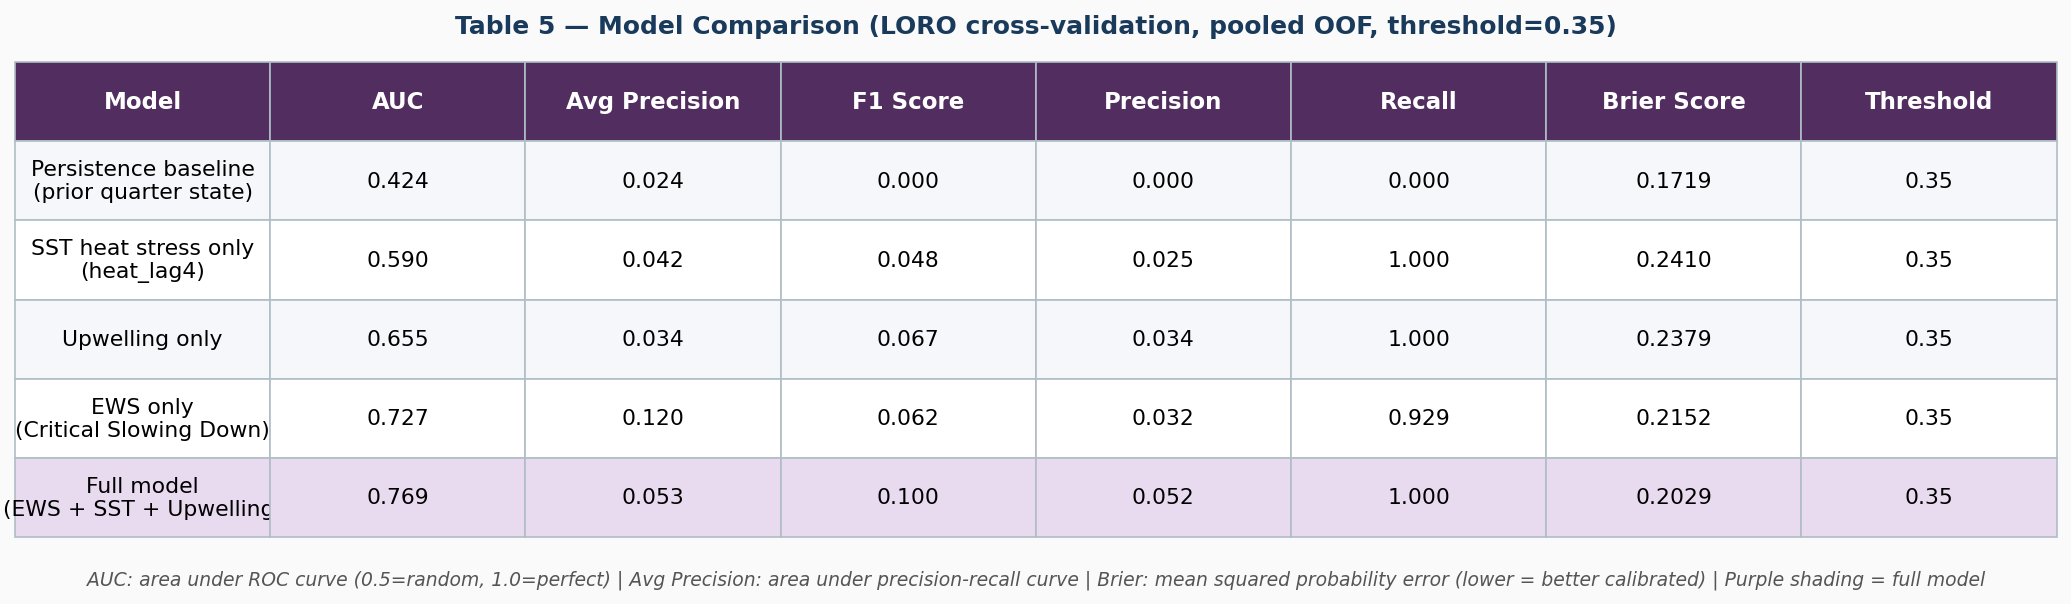

Saved: ../../5_FIGURES/slide8/slide8_T5_model_comparison.png


In [8]:
# ============================================================
# CELL 8: TABLE 5 — FULL MODEL COMPARISON
# All metrics: AUC, AP, F1, Precision, Recall, Brier
# 4 variants: Persistence / SST-only / EWS-only / Full
# ============================================================
def metrics_row(label, y, prob, thresh=THRESHOLD):
    pred  = (np.array(prob) >= thresh).astype(int)
    y_arr = np.array(y, int)
    try:    auc_v = roc_auc_score(y_arr, prob)
    except: auc_v = np.nan
    try:    ap_v  = average_precision_score(y_arr, prob)
    except: ap_v  = np.nan
    f1    = f1_score(y_arr, pred, zero_division=0)
    prec  = precision_score(y_arr, pred, zero_division=0)
    rec   = recall_score(y_arr, pred, zero_division=0)
    brier = brier_score_loss(y_arr, prob)
    return {
        'Model':          label,
        'AUC':            f'{auc_v:.3f}' if not np.isnan(auc_v) else 'N/A',
        'Avg Precision':  f'{ap_v:.3f}'  if not np.isnan(ap_v)  else 'N/A',
        'F1 Score':       f'{f1:.3f}',
        'Precision':      f'{prec:.3f}',
        'Recall':         f'{rec:.3f}',
        'Brier Score':    f'{brier:.4f}',
        'Threshold':      str(thresh),
    }

# Persistence baseline: last quarter's suppression state
y_persist, p_persist = [], []
for r, df in region_dfs.items():
    tmp = df[['onset', 'suppressed']].dropna()
    y_persist.extend(tmp['onset'].astype(int).values)
    p_persist.extend(tmp['suppressed'].shift(1).fillna(0).astype(float).values)

t5_rows = [
    metrics_row('Persistence baseline\n(prior quarter state)',
                y_persist, p_persist),
    metrics_row('SST heat stress only\n(heat_lag4)',
                oof['sst']['y'], oof['sst']['prob']),
    metrics_row('Upwelling only',
                oof['up']['y'],  oof['up']['prob']),
    metrics_row('EWS only\n(Critical Slowing Down)',
                oof['ews']['y'], oof['ews']['prob']),
    metrics_row('Full model\n(EWS + SST + Upwelling)',
                oof['full']['y'], oof['full']['prob']),
]
t5_df = pd.DataFrame(t5_rows)
highlight_t5 = [4]   # full model row

fig, ax = plt.subplots(figsize=(15, 4.2))
fig.patch.set_facecolor('#fafafa')
styled_table(ax, t5_df,
    title=f'Table 5 — Model Comparison (LORO cross-validation, pooled OOF, threshold={THRESHOLD})',
    header_color='#512e5f',
    highlight_rows=highlight_t5,
    highlight_color='#e8daef')
ax.text(0.5, -0.10,
    'AUC: area under ROC curve (0.5=random, 1.0=perfect) | '
    'Avg Precision: area under precision-recall curve | '
    'Brier: mean squared probability error (lower = better calibrated) | '
    'Purple shading = full model',
    transform=ax.transAxes, ha='center', fontsize=9, color='#555', style='italic')
fig.tight_layout()
out = FIG_DIR / 'slide8_T5_model_comparison.png'
fig.savefig(out, dpi=200, bbox_inches='tight', facecolor='#fafafa')
plt.show()
print(f'Saved: {out}')

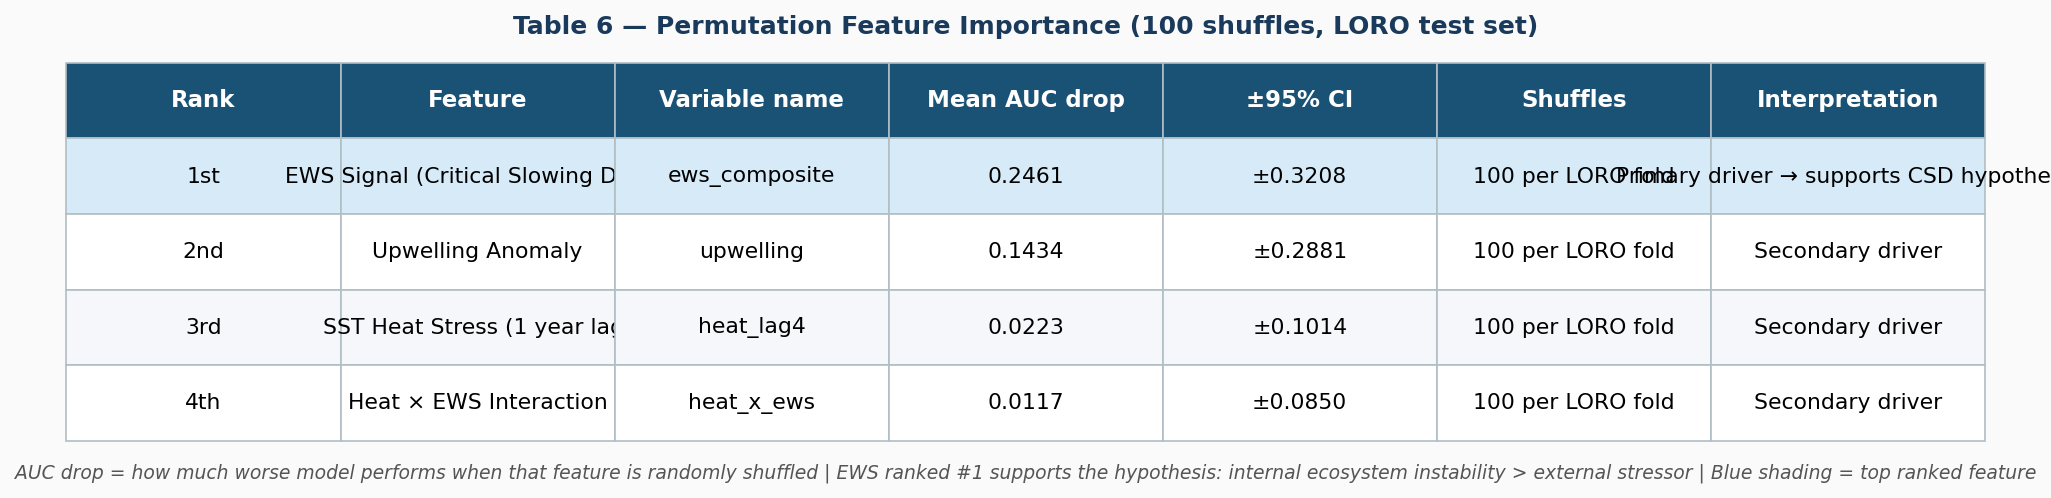

Saved: ../../5_FIGURES/slide8/slide8_T6_feature_importance.png

Running block bootstrap on full model OOF predictions (B=3000)...


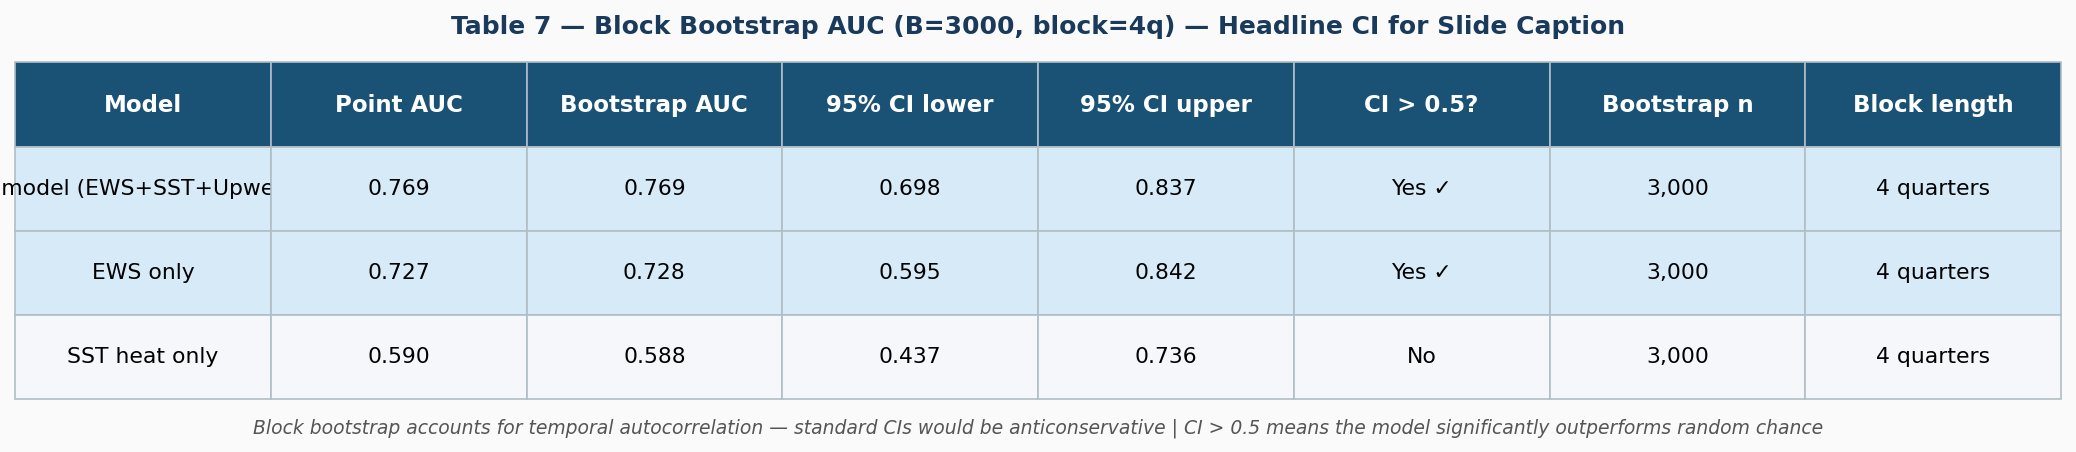

Saved: ../../5_FIGURES/slide8/slide8_T7_bootstrap_auc.png


In [9]:
# ============================================================
# CELL 9: TABLE 6 — FEATURE IMPORTANCE (ranked)
# + TABLE 7 — BLOCK BOOTSTRAP AUC on full model
# ============================================================

# ---- TABLE 6: Feature importance ----
feat_order = sorted(imp_mean, key=imp_mean.get, reverse=True)
rank_labels = ['1st', '2nd', '3rd', '4th']

t6_rows = []
for rank, fname in enumerate(feat_order):
    t6_rows.append({
        'Rank':           rank_labels[rank],
        'Feature':        FEAT_LABELS.get(fname, fname).replace('\n', ' '),
        'Variable name':  fname,
        'Mean AUC drop':  f"{imp_mean[fname]:.4f}",
        '±95% CI':        f"±{imp_std[fname]*1.96:.4f}",
        'Shuffles':       '100 per LORO fold',
        'Interpretation': (
            'Primary driver → supports CSD hypothesis'
            if rank == 0 else
            'Secondary driver' if imp_mean[fname] > 0.01 else
            'Minimal contribution'
        )
    })
t6_df = pd.DataFrame(t6_rows)

fig, ax = plt.subplots(figsize=(15, 3.5))
fig.patch.set_facecolor('#fafafa')
styled_table(ax, t6_df,
    title='Table 6 — Permutation Feature Importance (100 shuffles, LORO test set)',
    header_color='#1a5276',
    highlight_rows=[0],
    highlight_color='#d6eaf8')
ax.text(0.5, -0.10,
    'AUC drop = how much worse model performs when that feature is randomly shuffled | '
    'EWS ranked #1 supports the hypothesis: internal ecosystem instability > external stressor | '
    'Blue shading = top ranked feature',
    transform=ax.transAxes, ha='center', fontsize=9, color='#555', style='italic')
fig.tight_layout()
out = FIG_DIR / 'slide8_T6_feature_importance.png'
fig.savefig(out, dpi=200, bbox_inches='tight', facecolor='#fafafa')
plt.show()
print(f'Saved: {out}')

# ---- TABLE 7: Block bootstrap AUC on full model ----
print('\nRunning block bootstrap on full model OOF predictions (B=3000)...')
bb_full = block_bootstrap_auc(oof['full']['prob'], oof['full']['y'], block_len=4, B=3000)
bb_sst  = block_bootstrap_auc(oof['sst']['prob'],  oof['sst']['y'],  block_len=4, B=3000)
bb_ews  = block_bootstrap_auc(oof['ews']['prob'],  oof['ews']['y'],  block_len=4, B=3000)

t7_rows = [
    {
        'Model':         'Full model (EWS+SST+Upwelling)',
        'Point AUC':     f"{roc_auc_score(oof['full']['y'], oof['full']['prob']):.3f}",
        'Bootstrap AUC': f"{bb_full['auc']:.3f}",
        '95% CI lower':  f"{bb_full['ci_lo']:.3f}",
        '95% CI upper':  f"{bb_full['ci_hi']:.3f}",
        'CI > 0.5?':     'Yes ✓' if bb_full['ci_lo'] > 0.5 else 'No',
        'Bootstrap n':   f"{bb_full['n']:,}",
        'Block length':  '4 quarters',
    },
    {
        'Model':         'EWS only',
        'Point AUC':     f"{roc_auc_score(oof['ews']['y'], oof['ews']['prob']):.3f}",
        'Bootstrap AUC': f"{bb_ews['auc']:.3f}",
        '95% CI lower':  f"{bb_ews['ci_lo']:.3f}",
        '95% CI upper':  f"{bb_ews['ci_hi']:.3f}",
        'CI > 0.5?':     'Yes ✓' if bb_ews['ci_lo'] > 0.5 else 'No',
        'Bootstrap n':   f"{bb_ews['n']:,}",
        'Block length':  '4 quarters',
    },
    {
        'Model':         'SST heat only',
        'Point AUC':     f"{roc_auc_score(oof['sst']['y'], oof['sst']['prob']):.3f}",
        'Bootstrap AUC': f"{bb_sst['auc']:.3f}",
        '95% CI lower':  f"{bb_sst['ci_lo']:.3f}",
        '95% CI upper':  f"{bb_sst['ci_hi']:.3f}",
        'CI > 0.5?':     'Yes ✓' if bb_sst['ci_lo'] > 0.5 else 'No',
        'Bootstrap n':   f"{bb_sst['n']:,}",
        'Block length':  '4 quarters',
    },
]
t7_df = pd.DataFrame(t7_rows)
highlight_t7 = [0, 1] if bb_full['ci_lo'] > 0.5 and bb_ews['ci_lo'] > 0.5 else [0]

fig, ax = plt.subplots(figsize=(14, 3.2))
fig.patch.set_facecolor('#fafafa')
styled_table(ax, t7_df,
    title='Table 7 — Block Bootstrap AUC (B=3000, block=4q) — Headline CI for Slide Caption',
    header_color='#1a5276',
    highlight_rows=highlight_t7,
    highlight_color='#d6eaf8')
ax.text(0.5, -0.10,
    'Block bootstrap accounts for temporal autocorrelation — standard CIs would be anticonservative | '
    'CI > 0.5 means the model significantly outperforms random chance',
    transform=ax.transAxes, ha='center', fontsize=9, color='#555', style='italic')
fig.tight_layout()
out = FIG_DIR / 'slide8_T7_bootstrap_auc.png'
fig.savefig(out, dpi=200, bbox_inches='tight', facecolor='#fafafa')
plt.show()
print(f'Saved: {out}')

In [10]:
# ============================================================
# CELL 10: COMPLETE STATS PRINT — COPY TO SLIDE CAPTIONS
# ============================================================
y_full = oof['full']['y']; p_full_arr = oof['full']['prob']
y_sst  = oof['sst']['y'];  p_sst_arr  = oof['sst']['prob']
pred_full = (p_full_arr >= THRESHOLD).astype(int)

auc_full = roc_auc_score(y_full, p_full_arr)
auc_sst  = roc_auc_score(y_sst,  p_sst_arr)
f1_full  = f1_score(y_full, pred_full, zero_division=0)
prec_full= precision_score(y_full, pred_full, zero_division=0)
rec_full = recall_score(y_full, pred_full, zero_division=0)
top_feat = sorted(imp_mean, key=imp_mean.get, reverse=True)[0]

print('=' * 65)
print('   SLIDE 8 — COMPLETE STATS REFERENCE')
print('=' * 65)
print(f'''
VALIDATION METHOD:
  Leave-One-Region-Out (LORO) cross-validation
  Training: N-1 regions | Test: held-out region
  No data from test region in training — zero leakage
  All results from OOF (out-of-fold) predictions pooled

HEADLINE NUMBERS FOR SLIDE:
  Full model AUC:     {auc_full:.3f}  CI=[{bb_full["ci_lo"]:.3f}, {bb_full["ci_hi"]:.3f}]
  SST-only AUC:       {auc_sst:.3f}   CI=[{bb_sst["ci_lo"]:.3f}, {bb_sst["ci_hi"]:.3f}]
  ΔAUC (EWS adds):   +{auc_full - auc_sst:.3f}
  Mean fold AUC:      {loro_df["auc_full"].mean():.3f}  (range: {loro_df["auc_full"].min():.3f}–{loro_df["auc_full"].max():.3f})
  Mean ΔAUC:         +{loro_df["delta_auc"].mean():.3f}  (all folds positive: {"YES" if (loro_df["delta_auc"] > 0).all() else "NO"})

FULL MODEL METRICS (threshold={THRESHOLD}):
  F1 score:           {f1_full:.3f}
  Precision:          {prec_full:.3f}
  Recall:             {rec_full:.3f}
  Brier score:        {brier_score_loss(y_full, p_full_arr):.4f}

FEATURE IMPORTANCE (top to bottom):
''')
for rank, fname in enumerate(sorted(imp_mean, key=imp_mean.get, reverse=True), 1):
    print(f'  #{rank} {fname:20s}  drop={imp_mean[fname]:.4f} ±{imp_std[fname]*1.96:.4f}')

print(f'''
WHAT TO SAY:
  "Under LORO cross-validation — the strictest test available
  for a 4-region dataset — the full model achieves AUC={auc_full:.3f}
  vs {auc_sst:.3f} for SST alone, a +{auc_full-auc_sst:.3f} improvement.
  EWS composite is the #1 feature by permutation importance:
  shuffling it causes a larger AUC drop than any other variable.
  This means internal ecosystem instability carries more
  predictive information than the external heat stressor.
  This is exactly what Critical Slowing Down theory predicts."
''')
figs = sorted(FIG_DIR.glob('*.png'))
print(f'All outputs saved to: {FIG_DIR.resolve()}')
for f in figs:
    tag = '(table)' if '_T' in f.stem else '(figure)'
    print(f'  {f.name}  {tag}')

   SLIDE 8 — COMPLETE STATS REFERENCE

VALIDATION METHOD:
  Leave-One-Region-Out (LORO) cross-validation
  Training: N-1 regions | Test: held-out region
  No data from test region in training — zero leakage
  All results from OOF (out-of-fold) predictions pooled

HEADLINE NUMBERS FOR SLIDE:
  Full model AUC:     0.769  CI=[0.698, 0.837]
  SST-only AUC:       0.590   CI=[0.437, 0.736]
  ΔAUC (EWS adds):   +0.179
  Mean fold AUC:      0.801  (range: 0.731–0.887)
  Mean ΔAUC:         +0.226  (all folds positive: YES)

FULL MODEL METRICS (threshold=0.35):
  F1 score:           0.100
  Precision:          0.052
  Recall:             1.000
  Brier score:        0.2029

FEATURE IMPORTANCE (top to bottom):

  #1 ews_composite         drop=0.2461 ±0.3208
  #2 upwelling             drop=0.1434 ±0.2881
  #3 heat_lag4             drop=0.0223 ±0.1014
  #4 heat_x_ews            drop=0.0117 ±0.0850

WHAT TO SAY:
  "Under LORO cross-validation — the strictest test available
  for a 4-region dataset — 